In [1]:
import pandas as pd
import numpy as np
from statsbombpy import sb

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle
from mplsoccer import Pitch
import seaborn as sns

from position_identification_alg import *
from visualization_tool import *

from tqdm import tqdm

In [2]:
matches = sb.matches(2,27)

In [3]:
matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3754058,2016-01-02,16:00:00.000,England - Premier League,2015/2016,Leicester City,AFC Bournemouth,0,0,available,...,2021-06-12T16:17:31.694,20,Regular Season,King Power Stadium,Andre Marriner,Claudio Ranieri,Eddie Howe,1.1.0,2,2
1,3754245,2015-10-17,16:00:00.000,England - Premier League,2015/2016,West Bromwich Albion,Sunderland,1,0,available,...,2021-06-13T16:17:31.694,9,Regular Season,The Hawthorns,Martin Atkinson,Tony Pulis,Sam Allardyce,1.1.0,2,2
2,3754136,2015-12-19,18:30:00.000,England - Premier League,2015/2016,Newcastle United,Aston Villa,1,1,available,...,2021-06-13T16:17:31.694,17,Regular Season,St. James'' Park,Martin Atkinson,Steve McClaren,Rémi Garde,1.1.0,2,2
3,3754037,2016-04-30,16:00:00.000,England - Premier League,2015/2016,Everton,AFC Bournemouth,2,1,available,...,2021-06-12T16:17:31.694,36,Regular Season,Goodison Park,Neil Swarbrick,Roberto Martínez Montoliú,Eddie Howe,1.1.0,2,2
4,3754039,2016-02-13,16:00:00.000,England - Premier League,2015/2016,Crystal Palace,Watford,1,2,available,...,2021-06-12T16:17:31.694,26,Regular Season,Selhurst Park,Robert Madley,Alan Pardew,Enrique Sánchez Flores,1.1.0,2,2


In [4]:
matches.columns

Index(['match_id', 'match_date', 'kick_off', 'competition', 'season',
       'home_team', 'away_team', 'home_score', 'away_score', 'match_status',
       'match_status_360', 'last_updated', 'last_updated_360', 'match_week',
       'competition_stage', 'stadium', 'referee', 'home_managers',
       'away_managers', 'data_version', 'shot_fidelity_version',
       'xy_fidelity_version'],
      dtype='object')

In [7]:
valid_events = ['Pass', 'Ball Receipt*', 'Carry','Pressure', 'Dispossessed', 'Duel', 'Shot', 'Block'
       'Ball Recovery', 'Miscontrol', 'Clearance', 'Dribbled Past','Dribble', 'Interception', 'Foul Committed', 'Foul Won']

in_possession_events =  ['Pass', 'Ball Receipt*', 'Carry', 'Dispossessed', 'Shot', 'Miscontrol', 'Clearance','Dribble', 'Foul Won']

out_possession_events = ['Pressure', 'Duel', 'Block''Ball Recovery', 'Dribbled Past', 'Interception', 'Foul Committed']

all_role_probs = []

for i in tqdm(range(matches.shape[0])):
    match = matches.iloc[i]
    match_id = match.match_id
    home_team = match.home_team
    away_team = match.away_team
    teams = [home_team, away_team]
    
    events = sb.events(match_id)
    events["x"] = events["location"].str[0]
    events["y"] = 80 - events["location"].str[1] 
    
    for team in teams:
        team_match_events = events[events.team==team]
        
        starting_lineup = team_match_events[team_match_events.type=="Starting XI"].iloc[0].tactics["lineup"]
        players = [player["player"]["id"] for player in starting_lineup if player["position"]["name"]!="Goalkeeper"]
        team_subs = team_match_events[team_match_events.type == "Substitution"]
        
        
        valid_team_match_events = team_match_events[team_match_events.type.isin(valid_events)]
        valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]
        first_sub = team_subs.iloc[0]
        valid_team_match_events = valid_team_match_events[(valid_team_match_events.minute<=first_sub.minute)]
        valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
        duration = first_sub.minute
        player_dists, zone_probs_df, player_pos = position_calculations(valid_team_match_events)
        zone_probs_df["duration"] = duration

        for i in range(team_subs.shape[0]):

            valid_team_match_events = team_match_events[team_match_events.type.isin(valid_events)]
            valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]

            sub = team_subs.iloc[i]
            player_in = int(sub["substitution_replacement_id"])
            player_out = int(sub["player_id"])

            period = sub["period"]
            minute = sub["minute"]
            if player_out in players:
                players.remove(player_out)
            players.append(player_in)
            
            if i+1 < team_subs.shape[0]:
                next_sub = team_subs.iloc[i+1]
                next_period = next_sub["period"]
                next_minute = next_sub["minute"]
            else:
                max_minute =  team_match_events["minute"].max()
                next_period = 2
                next_minute = max_minute
            
            duration = next_minute-minute
            
            if duration >= 5: ### Otherwise algorithm might not work
                valid_team_match_events = valid_team_match_events[(valid_team_match_events.period >= period) & (valid_team_match_events.minute>=minute) & (valid_team_match_events.period <= next_period) & (valid_team_match_events.minute<=next_minute)]
                valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
                
                player_dists_sub, zone_probs_df_sub, player_pos_sub = position_calculations(valid_team_match_events)
                
                zone_probs_df_sub["duration"] = duration
                
                zone_probs_df = pd.concat([zone_probs_df,zone_probs_df_sub])
            
        def weighted_positioning(df):
            zone_cols = [c for c in df.columns if  c != "duration"]
            
            total_min = df["duration"].sum()
            
            weights = df["duration"] / total_min
            return (df[zone_cols].multiply(weights, axis=0)).sum()

        role_probs = zone_probs_df.groupby("player_id").apply(weighted_positioning)
        
        player_actual_position = (
            team_match_events
            .dropna(subset=["position"])
            .groupby("player_id")["position"]
            .first()
        )
        role_probs["actual_position"] = player_actual_position
        
        role_probs["team"] = team
        role_probs["match_id"] = match_id
        
        all_role_probs.append(role_probs)

 59%|█████▉    | 224/380 [14:28<11:49,  4.55s/it]c:\Users\zcoch\position_role_identification_event_data\position_identification_alg.py:94: RuntimeWarning: invalid value encountered in divide
  zone_probs /= zone_probs.sum()
c:\Users\zcoch\position_role_identification_event_data\position_identification_alg.py:112: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  player_pos = zone_probs_df.idxmax(axis=1)
 77%|███████▋  | 292/380 [18:52<05:59,  4.09s/it]c:\Users\zcoch\position_role_identification_event_data\position_identification_alg.py:94: RuntimeWarning: invalid value encountered in divide
  zone_probs /= zone_probs.sum()
c:\Users\zcoch\position_role_identification_event_data\position_identification_alg.py:112: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  player_p

In [9]:
all_role_probs = pd.concat(all_role_probs)

In [ ]:
# all_role_probs.to_csv("all_player_game_roles.csv")

In [46]:
all_role_probs = pd.read_csv("all_player_game_roles.csv").set_index("player_id")
all_role_probs = all_role_probs[all_role_probs.actual_position!="Goalkeeper"]

In [47]:
role_templates = all_role_probs.drop(["team","match_id"],axis=1).groupby("actual_position").mean()

In [48]:
role_templates

,RB,RWB,RM,RWF,RF,RCB,RDM,RCM,RAM,RCF,...,LCB,LDM,LCM,LAM,LCF,LB,LWB,LM,LWF,LF
actual_position,,,,,,,,,,,,,,,,,,,,,
Center Attacking Midfield,0.017549,0.025805,0.034220,0.040307,0.040906,0.021496,0.033215,0.045800,0.054296,0.054330,...,0.022891,0.036033,0.049103,0.057548,0.056691,0.018961,0.028097,0.037351,0.043188,0.043627
Center Back,0.049257,0.038357,0.026031,0.016910,0.011290,0.098295,0.075010,0.049371,0.031219,0.019412,...,0.071748,0.052536,0.034597,0.022778,0.014944,0.025560,0.020268,0.014097,0.009660,0.006488
Center Defensive Midfield,0.026140,0.033621,0.034153,0.029674,0.022709,0.046073,0.054178,0.053545,0.044534,0.031678,...,0.045658,0.052731,0.051118,0.041420,0.028654,0.027211,0.031807,0.031894,0.028091,0.021638
Center Forward,0.009401,0.017404,0.029196,0.043282,0.053326,0.012550,0.024069,0.041843,0.063383,0.078990,...,0.013076,0.024683,0.042154,0.063184,0.079032,0.009767,0.017913,0.029591,0.042861,0.051622
Left Attacking Midfield,0.007230,0.012191,0.019863,0.028334,0.031378,0.013335,0.022271,0.034744,0.046861,0.050323,...,0.024761,0.038825,0.056326,0.070928,0.074320,0.023504,0.036833,0.052624,0.062746,0.060125
Left Back,0.002741,0.002748,0.002671,0.002488,0.002142,0.002518,0.002549,0.002552,0.002493,0.002335,...,0.042770,0.043929,0.041092,0.035577,0.028240,0.152137,0.166536,0.164920,0.145584,0.116780
Left Center Back,0.007528,0.006238,0.004592,0.003227,0.002174,0.026749,0.020780,0.014349,0.009083,0.005500,...,0.142469,0.107189,0.066143,0.036142,0.018581,0.118107,0.091280,0.056662,0.030546,0.015471
Left Center Forward,0.010132,0.017792,0.027847,0.038396,0.045918,0.014184,0.025624,0.040174,0.057132,0.069617,...,0.016570,0.028583,0.045904,0.064928,0.076567,0.013297,0.022041,0.034210,0.047629,0.056366
Left Center Midfield,0.016796,0.021951,0.024244,0.022902,0.019020,0.028832,0.038722,0.042222,0.039108,0.031466,...,0.041895,0.056169,0.062170,0.057489,0.045812,0.031788,0.042070,0.046733,0.043586,0.035493


In [13]:
all_role_probs["actual_position"].value_counts()

actual_position
Center Forward               830
Right Center Back            802
Right Back                   801
Left Center Back             799
Left Back                    790
Right Wing                   690
Center Attacking Midfield    681
Left Wing                    678
Right Defensive Midfield     490
Left Defensive Midfield      479
Left Center Midfield         463
Right Center Midfield        458
Left Midfield                385
Right Midfield               376
Right Center Forward         252
Left Center Forward          233
Center Defensive Midfield    218
Left Wing Back                41
Right Wing Back               39
Center Back                   37
Left Attacking Midfield       18
Right Attacking Midfield      16
Goalkeeper                     6
Name: count, dtype: int64

In [14]:
def plot_position_template(position_name, template_df, nx=5, ny=5, ax=None):
    """
    Plots a 5x5 zone probability template for a given actual position.
    
    template_df:
        index = actual_position
        columns = zone labels (length nx*ny)
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure

    # Get 25 values
    probs = template_df.loc[position_name].values

    # Reshape to grid
    grid = probs.reshape(ny, nx)

    # Plot heatmap
    im = ax.imshow(grid, origin="lower")

    # Grid lines
    for i in range(1, nx):
        ax.axvline(i - 0.5, color="black", linewidth=1)
    for j in range(1, ny):
        ax.axhline(j - 0.5, color="black", linewidth=1)

    # Annotate probabilities
    for iy in range(ny):
        for ix in range(nx):
            ax.text(ix, iy,
                    round(grid[iy, ix], 3),
                    ha="center", va="center",
                    fontsize=8)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(position_name)

    return fig, ax

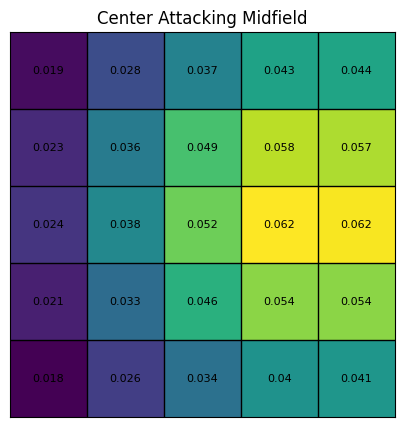

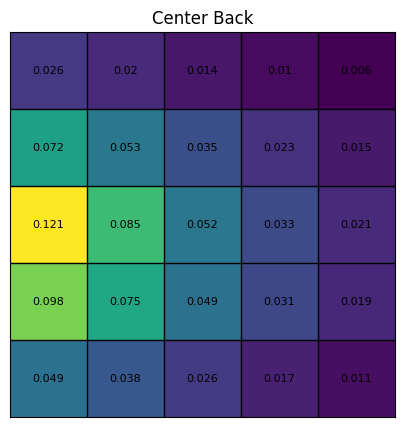

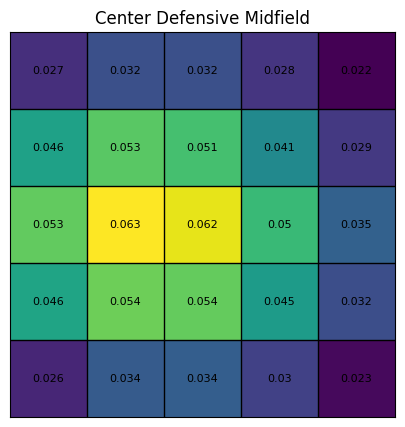

In [72]:
for role in role_templates.index[:3]:# Show just first 3
    plot_position_template(role,role_templates)
    plt.show()

![](imgs/Role_Templates.png)

After looking at the templates generated for each of Statsbombs positions we can see there is a lot of overlap between multiple positions. Right Midfield and Right Wing maps are incredibly similiar as well as Left Midfield and Left Wing, and finally Left Center Forward, Center Forward and Right Center Forward. For each of these three groups we can condense into one role for each group. Left Wing, Right Wing, and Center Forward.

In [61]:
role_templates = role_templates.drop(["Left Midfield","Right Midfield","Left Center Forward","Right Center Forward"],axis=0)

In [64]:
position_condense_map = {"Left Midfield":"Left Wing","Right Midfield":"Right Wing","Left Center Forward":"Center Forward","Right Center Forward":"Center Forward"}
all_role_probs["actual_position_condensed"] = all_role_probs["actual_position"].apply(lambda pos: pos if pos not in position_condense_map else position_condense_map[pos])

![](imgs/Role_Templates_Condensed.png)

In [66]:
from scipy.spatial.distance import jensenshannon
import numpy as np

def js_similarity(A, B):
    p = np.asarray(A, dtype=np.float64).flatten()
    q = np.asarray(B, dtype=np.float64).flatten()

    # normalize just in case
    p = p / p.sum()
    q = q / q.sum()

    return jensenshannon(p, q)

In [67]:
player_role_map = all_role_probs.iloc[0].values[:25]
role_similiarities = pd.Series()
for role in role_templates.index:
    role_template = role_templates.loc[role].values
    role_similiarities[role] = js_similarity(player_role_map,role_template)
probable_role = role_similiarities.idxmin()

In [68]:
def player_role_map_to_role(row):
    role_map = row.values[:25]
    role_similiarities = pd.Series()
    for role in role_templates.index:
        role_template = role_templates.loc[role].values
        role_similiarities[role] = js_similarity(role_map,role_template)
    probable_role = role_similiarities.idxmin()
    return probable_role
all_role_probs["predicted_role"] = all_role_probs.apply(player_role_map_to_role,axis=1)

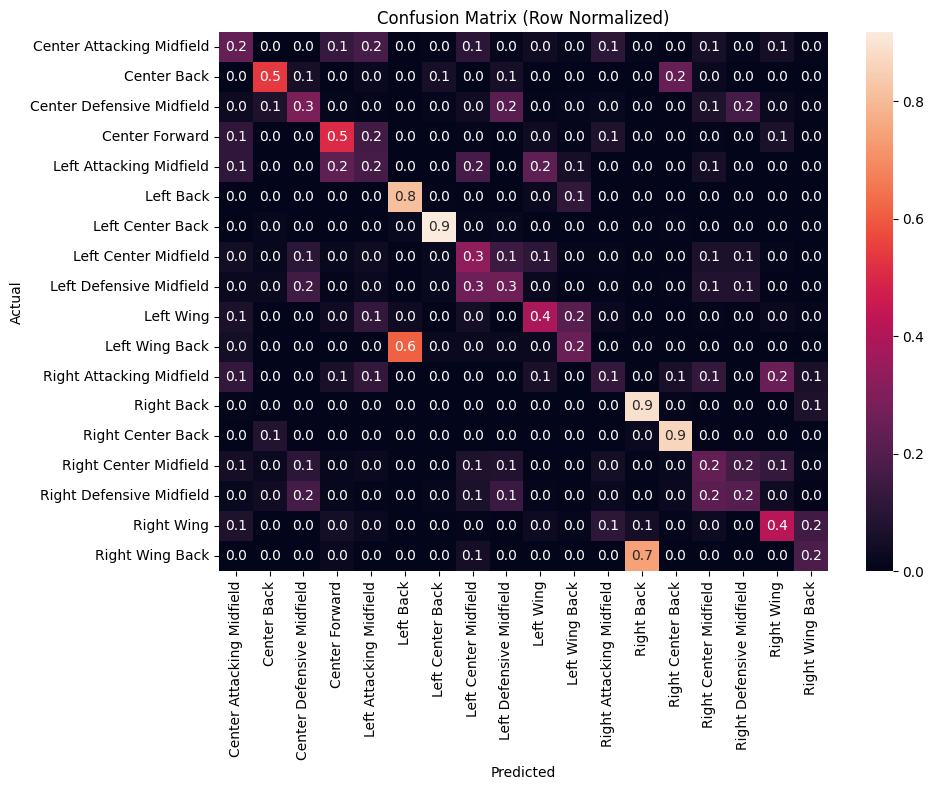

In [69]:
conf_matrix_norm = pd.crosstab(
    all_role_probs["actual_position_condensed"],
    all_role_probs["predicted_role"],
    normalize="index"
)

conf_matrix_norm
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_norm, annot=True, fmt=".1f")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix (Row Normalized)")
plt.tight_layout()
plt.show()